#### Plot monthly wave flux @ PacWave

In [25]:
import mhkit
from mhkit.wave import resource, performance, graphics, contours
from sklearn.mixture import GaussianMixture
from mhkit.wave.io import ndbc
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy import stats
import pandas as pd
import numpy as np
import folium
import os

import matplotlib.pylab as pylab

params = {
    "legend.fontsize": "x-large",
    "figure.figsize": (15, 5),
    "axes.labelsize": "x-large",
    "axes.titlesize": "x-large",
    "xtick.labelsize": "x-large",
    "ytick.labelsize": "x-large",
}
pylab.rcParams.update(params)

In [26]:
m = folium.Map(
    location=[44.613600975457715, -123.74317583354498],
    zoom_start=9,
    tiles="OpenStreetMap",
    attr="Map data © OpenStreetMap contributors",
    control_scale=True,
)

tooltip = "NDBC 46050"
folium.Marker(
    [44.669, -124.546], popup="<i> Water depth: 160 m</i>", tooltip=tooltip
).add_to(m)

tooltip = "PACWAVE North"
folium.Marker(
    [44.69, -124.13472222222222],
    tooltip=tooltip,
    icon=folium.Icon(color="green", icon="th-large"),
).add_to(m)

tooltip = "PACWAVE South"
folium.Marker(
    [44.58444444444444, -124.2125],
    tooltip=tooltip,
    icon=folium.Icon(color="red", icon="th"),
).add_to(m)

m.save("index.png")

m

In [ ]:
# Get NDBC buoy metadata
#buoy_number = "46050" # PacWave Site, OR
buoy_number = "44014" # Virginia Beach, VA
buoy_metadata = ndbc.get_buoy_metadata(buoy_number)
print("Buoy Metadata:")
for key, value in buoy_metadata.items():
    print(f"{key}: {value}")

Buoy Metadata:
buoy: Station 44014(LLNR 550)- VIRGINIA BEACH 64 NM East of Virginia Beach, VA
provider: Owned and maintained by National Data Buoy Center
type: 2.1-meter ionomer foam buoy
SCOOP payload: 
lat: 36.603
lon: 74.837
Site elevation: sea level
Air temp height: 2.8 m above site elevation
Anemometer height: 3.2 m above site elevation
Barometer elevation: 1.8 m above mean sea level
Sea temp depth: 1.1 m below water line
Water depth: 49.1 m
Watch circle radius: 102 yards


In [42]:
# Specify Spectral wave density 
parameter = "swden"

# Request list of available files#
ndbc_available_data = ndbc.available_data(parameter, buoy_number)
print(ndbc_available_data)

# Pass file names to NDBC and request the data
filenames = ndbc_available_data["filename"]
ndbc_requested_data = ndbc.request_data(parameter, filenames)

ndbc_requested_data["2015"]

         id  year            filename
1060  44014  1996   44014w1996.txt.gz
1061  44014  1997   44014w1997.txt.gz
1062  44014  1998   44014w1998.txt.gz
1063  44014  1999   44014w1999.txt.gz
1064  44014  2000   44014w2000.txt.gz
1065  44014  2001   44014w2001.txt.gz
1066  44014  2002   44014w2002.txt.gz
1067  44014  2003   44014w2003.txt.gz
1068  44014  2004   44014w2004.txt.gz
1069  44014  2005   44014w2005.txt.gz
1070  44014  2006   44014w2006.txt.gz
1071  44014  2007   44014w2007.txt.gz
1072  44014  2008   44014w2008.txt.gz
1073  44014  2009   44014w2009.txt.gz
1074  44014  2010   44014w2010.txt.gz
1075  44014  2011   44014w2011.txt.gz
1076  44014  2012   44014w2012.txt.gz
1077  44014  2013   44014w2013.txt.gz
1078  44014  2014   44014w2014.txt.gz
1079  44014  2015   44014w2015.txt.gz
1080  44014  2016   44014w2016.txt.gz
1081  44014  2017   44014w2017.txt.gz
1082  44014  2018   44014w2018.txt.gz
1083  44014  2019   44014w2019.txt.gz
1084  44014  2020   44014w2020.txt.gz
1085  44014 

,#YY,MM,DD,hh,mm,.0200,.0325,.0375,.0425,.0475,...,.3300,.3400,.3500,.3650,.3850,.4050,.4250,.4450,.4650,.4850
0,2015,1,1,0,0,0.0,0.0,0.0,0.0,0.0,...,0.18,0.12,0.09,0.04,0.04,0.04,0.03,0.03,0.01,0.01
1,2015,1,1,1,0,0.0,0.0,0.0,0.0,0.0,...,0.12,0.07,0.07,0.03,0.04,0.02,0.02,0.02,0.01,0.01
2,2015,1,1,2,0,0.0,0.0,0.0,0.0,0.0,...,0.17,0.07,0.06,0.04,0.03,0.03,0.02,0.02,0.01,0.01
3,2015,1,1,3,0,0.0,0.0,0.0,0.0,0.0,...,0.12,0.05,0.05,0.03,0.03,0.03,0.01,0.01,0.01,0.01
4,2015,1,1,4,0,0.0,0.0,0.0,0.0,0.0,...,0.04,0.09,0.02,0.04,0.01,0.01,0.01,0.02,0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8334,2015,12,31,19,0,0.0,0.0,0.0,0.0,0.0,...,0.12,0.05,0.10,0.07,0.08,0.06,0.05,0.04,0.02,0.01
8335,2015,12,31,20,0,0.0,0.0,0.0,0.0,0.0,...,0.05,0.08,0.06,0.09,0.06,0.07,0.04,0.03,0.02,0.01
8336,2015,12,31,21,0,0.0,0.0,0.0,0.0,0.0,...,0.12,0.17,0.13,0.11,0.10,0.02,0.03,0.05,0.02,0.02
8337,2015,12,31,22,0,0.0,0.0,0.0,0.0,0.0,...,0.10,0.07,0.14,0.11,0.08,0.09,0.06,0.02,0.02,0.02


In [44]:
ndbc_data = {}
# Create a Datetime Index and remove NOAA date columns for each year
for year in ndbc_requested_data:
    year_data = ndbc_requested_data[year]
    ndbc_data[year] = ndbc.to_datetime_index(parameter, year_data)

ndbc_data["2015"]

,0.0200,0.0325,0.0375,0.0425,0.0475,0.0525,0.0575,0.0625,0.0675,0.0725,...,0.3300,0.3400,0.3500,0.3650,0.3850,0.4050,0.4250,0.4450,0.4650,0.4850
date,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.01,...,0.18,0.12,0.09,0.04,0.04,0.04,0.03,0.03,0.01,0.01
2015-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.04,0.05,...,0.12,0.07,0.07,0.03,0.04,0.02,0.02,0.02,0.01,0.01
2015-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.01,...,0.17,0.07,0.06,0.04,0.03,0.03,0.02,0.02,0.01,0.01
2015-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.01,...,0.12,0.05,0.05,0.03,0.03,0.03,0.01,0.01,0.01,0.01
2015-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.02,...,0.04,0.09,0.02,0.04,0.01,0.01,0.01,0.02,0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.04,0.05,...,0.12,0.05,0.10,0.07,0.08,0.06,0.05,0.04,0.02,0.01
2015-12-31 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,...,0.05,0.08,0.06,0.09,0.06,0.07,0.04,0.03,0.02,0.01
2015-12-31 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,...,0.12,0.17,0.13,0.11,0.10,0.02,0.03,0.05,0.02,0.02


In [49]:
# Intialize empty lists to store the results from each year
Hm0_list = []
Te_list = []
J_list = []
Tp_list = []
Tz_list = []

# Iterate over each year and save the result in the initalized dictionary
for year in ndbc_data:
    data_raw = ndbc_data[year]
    year_data = data_raw[data_raw != 999.0].dropna()
    Hm0_list.append(resource.significant_wave_height(year_data.T))
    Te_list.append(resource.energy_period(year_data.T))
    J_list.append(resource.energy_flux(year_data.T, h=399.0))

    # Tp_list.append(resource.peak_period(year_data.T))
    fp = year_data.T.idxmax(axis=0)
    Tp = 1/fp
    Tp = pd.DataFrame(Tp, index=year_data.T.columns, columns=["Tp"])
    Tp_list.append(Tp)

    Tz_list.append(resource.average_zero_crossing_period(year_data.T))

# Concatenate each list of Series into a single Series
Te = pd.concat(Te_list, axis=0)
Tp = pd.concat(Tp_list, axis=0)
Hm0 = pd.concat(Hm0_list, axis=0)
J = pd.concat(J_list, axis=0)
Tz = pd.concat(Tz_list, axis=0)

# Name each Series and concat into a dataFrame
Te.name = 'Te'
Tp.name = 'Tp'
Hm0.name = 'Hm0'
J.name = 'J'
Tz.name = 'Tz'
data = pd.concat([Hm0, Te, Tp, J, Tz], axis=1)

# Calculate wave steepness
data["Sm"] = data.Hm0 / (9.81 / (2 * np.pi) * data.Tz**2)

# Drop any NaNs created from the calculation of Hm0 or Te
data.dropna(inplace=True)
# Sort the DateTime index
data.sort_index(inplace=True)

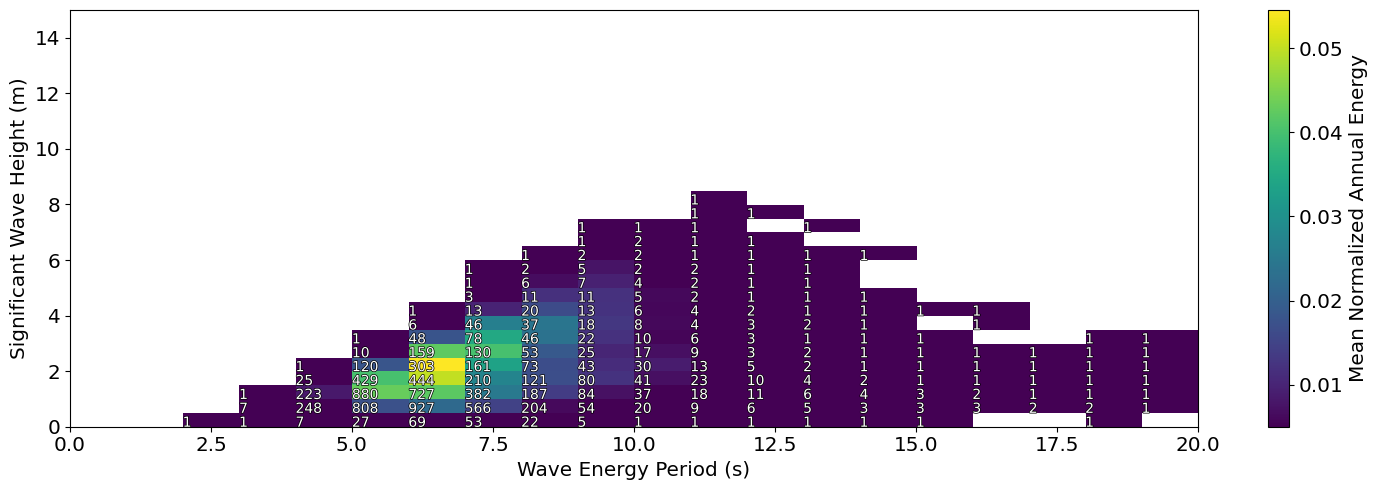

In [50]:
# Start by cleaning the data of outliers
data_clean = data[data.Hm0 < 20]
sigma = data_clean.J.std()
data_clean = data_clean[data_clean.J > (data_clean.J.mean() - 0.9 * sigma)]

# Organizing the cleaned data
Hm0 = data_clean.Hm0
Te = data_clean.Te
J = data_clean.J

# Setting the bins for the resource frequency and power distribution
Hm0_bin_size = 0.5
Hm0_edges = np.arange(0, 15 + Hm0_bin_size, Hm0_bin_size)
Te_bin_size = 1
Te_edges = np.arange(0, 20 + Te_bin_size, Te_bin_size)

fig = mhkit.wave.graphics.plot_avg_annual_energy_matrix(
    Hm0, Te, J, Hm0_edges=Hm0_edges, Te_edges=Te_edges
)

--------------------------------------------
Hm0 max:3.0424, month: 12
Hm0 min:1.426, month: 8
--------------------------------------------
Te max:10.3586, month: 1
Te min:7.0789, month: 7
--------------------------------------------
Tp max:12.5, month: 1
Tp min:8.3333, month: 7
--------------------------------------------
J max:45919.3605, month: 1
J min:7061.094, month: 8
--------------------------------------------
Tz max:7.9985, month: 1
Tz min:5.6727, month: 7
--------------------------------------------
Sm max:0.0318, month: 12
Sm min:0.0265, month: 9


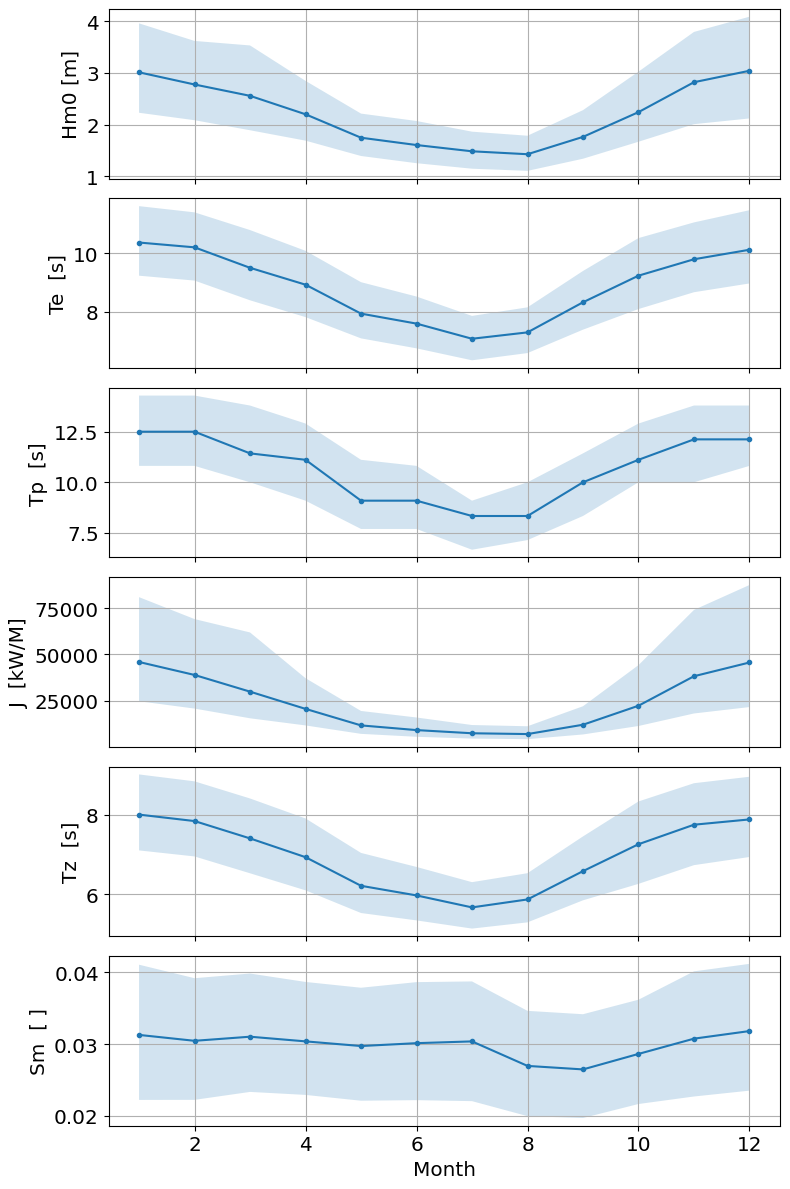

In [32]:
months = data_clean.index.month
data_group = data_clean.groupby(months)

QoIs = data_clean.keys()
fig, axs = plt.subplots(len(QoIs), 1, figsize=(8, 12), sharex=True)
# shade between 25% and 75%
QoIs = data_clean.keys()
for i in range(len(QoIs)):
    QoI = QoIs[i]
    axs[i].plot(data_group.median()[QoI], marker=".")

    axs[i].fill_between(
        months.unique(),
        data_group.describe()[QoI, "25%"],
        data_group.describe()[QoI, "75%"],
        alpha=0.2,
    )
    axs[i].grid()
    mx = data_group.median()[QoI].max()
    mx_month = data_group.median()[QoI].argmax() + 1
    mn = data_group.median()[QoI].min()
    mn_month = data_group.median()[QoI].argmin() + 1
    print("--------------------------------------------")
    print(f"{QoI} max:{np.round(mx,4)}, month: {mx_month}")
    print(f"{QoI} min:{np.round(mn,4)}, month: {mn_month}")

plt.setp(axs[5], xlabel="Month")

plt.setp(axs[0], ylabel=f"{QoIs[0]} [m]")
plt.setp(axs[1], ylabel=f"{QoIs[1]}  [s]")
plt.setp(axs[2], ylabel=f"{QoIs[2]}  [s]")
plt.setp(axs[3], ylabel=f"{QoIs[3]}  [kW/M]")
plt.setp(axs[4], ylabel=f"{QoIs[4]}  [s]")
plt.setp(axs[5], ylabel=f"{QoIs[5]}  [ ]")


plt.tight_layout()

plt.savefig("Delicious-Style.png")